In [6]:
#importing the required libraries
from matplotlib import pyplot as plt
from matplotlib import dates as mpl_dates
import numpy as np
from numpy import genfromtxt
import pandas as pd
from pandas import Series
from datetime import datetime, timedelta
from pandas.plotting import register_matplotlib_converters
#reading data from csv file 
headers = ['Date','Open','High','Low','Close','Volume']
data = pd.read_csv('stock_data.csv',sep=',',names=headers)
data.head()

,Date,Open,High,Low,Close,Volume
0,1/1/2017,1443.38,1476.82,1443.80,1465.72,561280000.0
1,1/2/2017,1465.72,1484.89,1465.72,1482.85,494264992.0
2,1/3/2017,1482.85,1484.26,1456.69,1456.82,385836992.0
3,1/4/2017,1456.82,1462.83,1442.51,1457.82,320670016.0
4,1/5/2017,1457.82,1465.72,1451.36,1454.14,326768000.0


In [7]:
date = pd.to_datetime(data['Date'])
dataset=data['Close'].to_frame()
dataset=dataset.set_index(date)
dataset = dataset.resample('W').mean()
print(dataset)

               Close
Date                
2017-01-01  1465.720
2017-01-08  1459.816
2017-01-15  1473.992
2017-01-22  1463.952
2017-01-29  1415.655
...              ...
2019-12-08  1123.898
2019-12-15  1160.444
2019-12-22  1152.135
2019-12-29  1166.532
2020-01-05  1166.990

[158 rows x 1 columns]


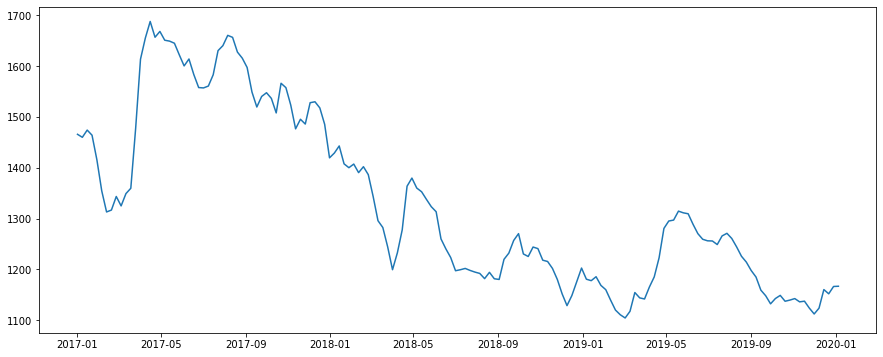

In [8]:
plt.rcParams['figure.figsize']=(15,6)
plt.plot(dataset)
plt.show()

In [18]:
from pmdarima.arima import auto_arima
stepwise_model = auto_arima(dataset, start_p=1, start_q=1,
                           max_p=3, max_q=3, m=14,
                           start_P=0,max_P=3,start_Q=1, seasonal=True,
                           start_d=1, start_D=1,max_d=2, trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)
print(stepwise_model.aic())

Performing stepwise search to minimize aic
Fit ARIMA(1,1,1)x(0,0,1,14) [intercept=True]; AIC=1467.340, BIC=1482.621, Time=0.322 seconds
Fit ARIMA(0,1,0)x(0,0,0,14) [intercept=True]; AIC=1496.341, BIC=1502.453, Time=0.011 seconds
Fit ARIMA(1,1,0)x(1,0,0,14) [intercept=True]; AIC=1465.747, BIC=1477.972, Time=0.198 seconds
Fit ARIMA(0,1,1)x(0,0,1,14) [intercept=True]; AIC=1469.088, BIC=1481.313, Time=0.297 seconds
Fit ARIMA(0,1,0)x(0,0,0,14) [intercept=False]; AIC=1495.062, BIC=1498.118, Time=0.010 seconds
Fit ARIMA(1,1,0)x(0,0,0,14) [intercept=True]; AIC=1463.875, BIC=1473.044, Time=0.054 seconds
Fit ARIMA(1,1,0)x(0,0,1,14) [intercept=True]; AIC=1465.737, BIC=1477.962, Time=0.179 seconds
Fit ARIMA(1,1,0)x(1,0,1,14) [intercept=True]; AIC=1467.723, BIC=1483.005, Time=0.469 seconds
Fit ARIMA(2,1,0)x(0,0,0,14) [intercept=True]; AIC=1465.407, BIC=1477.632, Time=0.094 seconds
Fit ARIMA(1,1,1)x(0,0,0,14) [intercept=True]; AIC=1465.462, BIC=1477.687, Time=0.140 seconds
Fit ARIMA(0,1,1)x(0,0,0,14